# Image Captioning — Data & Training
**Architecture:** CNN Encoder (EfficientNet-B0, pretrained) + Transformer Decoder  
**Dataset:** Flickr8k-style — 8 000 images, 5 captions each  
**Platform:** Kaggle (GPU P100 / T4)

## 0. Install / Import

In [1]:
# Kaggle already has torch, torchvision, timm — nothing extra needed
import os, re, math, json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import torchvision.transforms as T
import timm                          # EfficientNet backbone

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 1. Data Loading — Download from Kaggle Hub

In [2]:
import kagglehub

# Downloads to ~/.cache/kagglehub/datasets/giorgicheishvili/caption-data/
dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)
print("Contents:", list(dataset_path.iterdir()))

Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data
Contents: [PosixPath('/kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt'), PosixPath('/kaggle/input/datasets/giorgicheishvili/caption-data/Images')]


In [3]:
# ── Locate images folder and captions file ──────────────────────────────────
# The zip contains an 'Images/' folder and 'captions.txt'
IMAGES_DIR  = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

# Fallback: search one level deeper if structure differs
if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))

Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [4]:
# ── Load captions CSV ────────────────────────────────────────────────────────
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows  : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)

Total rows  : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


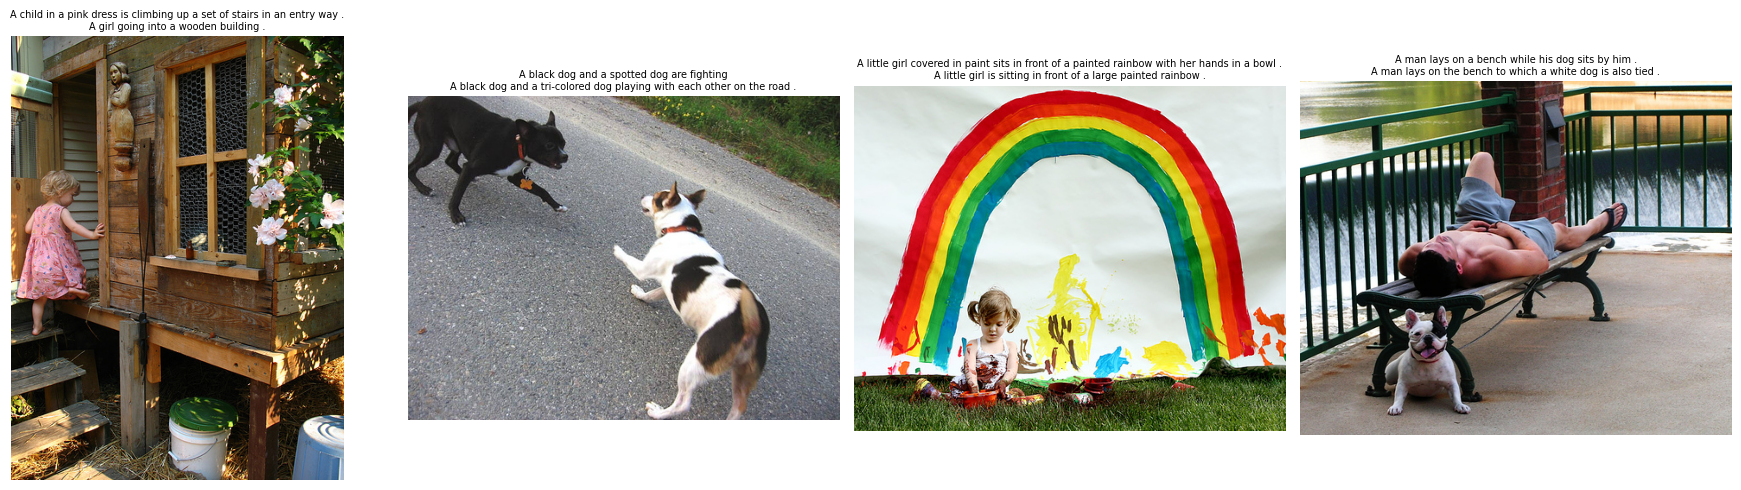

In [5]:
# ── Sanity check: show a few images with their captions ──────────────────────
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Preprocessing — Vocabulary & Tokenisation

In [6]:
# ── Text cleaning ────────────────────────────────────────────────────────────
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]", " ", text)   # keep letters, digits, apostrophe
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['caption_clean'] = df['caption'].apply(clean_caption)
df[['caption', 'caption_clean']].head(4)

,caption,caption_clean
0,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...
1,A girl going into a wooden building .,a girl going into a wooden building
2,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse
3,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...


In [7]:
# ── Build vocabulary ─────────────────────────────────────────────────────────
# Special tokens
PAD_TOKEN   = "<pad>"    # 0  — padding
START_TOKEN = "<start>"  # 1  — beginning of sequence
END_TOKEN   = "<end>"    # 2  — end of sequence
UNK_TOKEN   = "<unk>"    # 3  — unknown word
MIN_FREQ    = 5          # words appearing < 5 times → <unk>

all_words = []
for cap in df['caption_clean']:
    all_words.extend(cap.split())

word_freq = Counter(all_words)
vocab_words = [w for w, c in word_freq.items() if c >= MIN_FREQ]

word2idx = {
    PAD_TOKEN:   0,
    START_TOKEN: 1,
    END_TOKEN:   2,
    UNK_TOKEN:   3,
}
for w in sorted(vocab_words):
    word2idx[w] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Total unique words in corpus: {len(word_freq)}")
print(f"Words kept (freq >= {MIN_FREQ}): {len(vocab_words)}")

Vocabulary size : 2982
Total unique words in corpus: 8493
Words kept (freq >= 5): 2978


In [8]:
# ── Tokenise captions → integer sequences ────────────────────────────────────
def tokenise(caption: str) -> list[int]:
    tokens = [word2idx[START_TOKEN]]
    for w in caption.split():
        tokens.append(word2idx.get(w, word2idx[UNK_TOKEN]))
    tokens.append(word2idx[END_TOKEN])
    return tokens

df['tokens'] = df['caption_clean'].apply(tokenise)

# Caption length statistics
lengths = df['tokens'].apply(len)
print(f"Caption lengths — mean: {lengths.mean():.1f}, max: {lengths.max()}, 95th pct: {lengths.quantile(0.95):.0f}")

MAX_SEQ_LEN = int(lengths.quantile(0.98))   # cover 98 % of captions
print(f"MAX_SEQ_LEN set to: {MAX_SEQ_LEN}")

Caption lengths — mean: 12.8, max: 39, 95th pct: 20
MAX_SEQ_LEN set to: 22


## 3. Train / Validation Split

In [9]:
# Split on image level (not row level) so no image leaks across splits
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split = int(0.90 * len(all_images))          # 90 / 10 split
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")

Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 4. Dataset & DataLoader

In [10]:
# ── Image transforms ─────────────────────────────────────────────────────────
IMG_SIZE = 224    # EfficientNet-B0 expects 224×224

train_transform = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                std =[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

In [11]:
class CaptionDataset(Dataset):
    """
    Each sample = (image_tensor, caption_tokens).
    During training every (image, caption) pair is one sample,
    so each image appears 5 times with different captions.
    """
    def __init__(self, dataframe, images_dir, transform, max_len):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.transform  = transform
        self.max_len    = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(self.images_dir / row['image']).convert("RGB")
        img    = self.transform(img)                      # [3, H, W]

        tokens = row['tokens'][:self.max_len]             # truncate if needed
        tokens = torch.tensor(tokens, dtype=torch.long)
        return img, tokens


def collate_fn(batch):
    """Pad captions in a batch to the same length."""
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs, dim=0)                       # [B, 3, H, W]
    caps = pad_sequence(caps, batch_first=True,
                        padding_value=word2idx[PAD_TOKEN]) # [B, T]
    return imgs, caps

In [12]:
BATCH_SIZE  = 64
NUM_WORKERS = 2

train_dataset = CaptionDataset(train_df, IMAGES_DIR, train_transform, MAX_SEQ_LEN)
val_dataset   = CaptionDataset(val_df,   IMAGES_DIR, val_transform,   MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

# Quick shape check
imgs_b, caps_b = next(iter(train_loader))
print(f"Image batch : {imgs_b.shape}")
print(f"Caption batch: {caps_b.shape}")

Train batches: 569
Val   batches: 64
Image batch : torch.Size([64, 3, 224, 224])
Caption batch: torch.Size([64, 22])


## 5. Model Definition

### Architecture: EfficientNet-B0 Encoder + Transformer Decoder

```
Image [B,3,224,224]
  │
  ▼
EfficientNet-B0 (pretrained, features only)
  │  → feature map [B, 1280, 7, 7]
  ▼
Flatten spatial dims  →  [B, 49, 1280]
  │
  ▼
Linear projection  →  [B, 49, D_MODEL]
  │
  ├─────────────── encoder output (memory)
  │
Caption tokens [B, T]
  │
  ▼
Embedding + Positional Encoding  →  [B, T, D_MODEL]
  │
  ▼
Transformer Decoder (N layers, causal mask)
  │  cross-attends to image memory
  ▼
Linear head  →  [B, T, VOCAB_SIZE]
```

In [13]:
# ── 5.1  CNN Encoder ─────────────────────────────────────────────────────────
class ImageEncoder(nn.Module):
    """
    EfficientNet-B0 feature extractor.
    Returns spatial feature tokens: [B, num_patches, encoder_dim]
    where num_patches = 7*7 = 49 for 224x224 input.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, freeze_until: int = 7):
        super().__init__()
        # Load pretrained EfficientNet-B0, strip classifier head
        backbone = timm.create_model('efficientnet_b0', pretrained=True,
                                     features_only=False, num_classes=0,
                                     global_pool='')
        # Keep everything except the final pooling + classifier
        # timm exposes backbone.forward_features() which returns [B,1280,7,7]
        self.backbone      = backbone
        self.encoder_dim   = backbone.num_features   # 1280 for B0
        self.proj          = nn.Linear(self.encoder_dim, d_model)
        self.norm          = nn.LayerNorm(d_model)
        self.dropout       = nn.Dropout(dropout)

        # Freeze early layers to preserve pretrained low-level features
        blocks = list(self.backbone.named_children())
        for name, layer in blocks[:freeze_until]:
            for p in layer.parameters():
                p.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 3, 224, 224]
        feats = self.backbone.forward_features(x)   # [B, 1280, 7, 7]
        B, C, H, W = feats.shape
        feats = feats.permute(0, 2, 3, 1)            # [B, H, W, C]
        feats = feats.reshape(B, H * W, C)           # [B, 49, 1280]
        feats = self.proj(feats)                     # [B, 49, d_model]
        feats = self.norm(feats)
        feats = self.dropout(feats)
        return feats                                 # memory for decoder

In [14]:
# ── 5.2  Positional Encoding ─────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """Classic sinusoidal positional encoding (Vaswani et al., 2017)."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                          # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, d_model]
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [15]:
# ── 5.3  Transformer Decoder-based Caption Generator ─────────────────────────
class CaptionDecoder(nn.Module):
    """
    Transformer decoder that cross-attends to image features (memory)
    and auto-regressively generates caption tokens.
    """
    def __init__(self, vocab_size: int, d_model: int, n_heads: int,
                 n_layers: int, d_ff: int, max_len: int, dropout: float):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model,
                                    padding_idx=word2idx[PAD_TOKEN])
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)
        self.d_model     = d_model

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)
        nn.init.normal_(self.embed.weight, mean=0.0, std=self.d_model ** -0.5)

    @staticmethod
    def _causal_mask(sz: int, device) -> torch.Tensor:
        """Upper-triangular mask so position i cannot attend to j > i."""
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, tgt: torch.Tensor,
                memory: torch.Tensor,
                tgt_pad_mask: torch.Tensor = None) -> torch.Tensor:
        """
        tgt          : [B, T]         — token ids (teacher-forced)
        memory       : [B, S, d_model] — encoder output
        tgt_pad_mask : [B, T]         — True where padding
        Returns logits [B, T, vocab_size]
        """
        T = tgt.size(1)
        x = self.embed(tgt) * math.sqrt(self.d_model)  # [B, T, d]
        x = self.pos_enc(x)

        causal = self._causal_mask(T, tgt.device)
        out    = self.transformer(
            tgt=x,
            memory=memory,
            tgt_mask=causal,
            tgt_key_padding_mask=tgt_pad_mask,
        )                                               # [B, T, d]
        logits = self.fc_out(out)                       # [B, T, vocab_size]
        return logits

In [16]:
# ── 5.4  Full model ───────────────────────────────────────────────────────────
class ImageCaptioner(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=4,
                 d_ff=2048, max_len=64, dropout=0.1):
        super().__init__()
        self.encoder = ImageEncoder(d_model=d_model, dropout=dropout)
        self.decoder = CaptionDecoder(
            vocab_size=vocab_size, d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, d_ff=d_ff, max_len=max_len, dropout=dropout
        )

    def forward(self, images, captions):
        """
        images   : [B, 3, H, W]
        captions : [B, T]  — includes <start> token, teacher-forced
        Returns logits [B, T-1, vocab_size]  (predict next token for each position)
        """
        memory       = self.encoder(images)              # [B, 49, d]
        tgt          = captions[:, :-1]                  # input:  <start> w1 w2 ... wN
        tgt_pad_mask = (tgt == word2idx[PAD_TOKEN])      # [B, T-1]
        logits       = self.decoder(tgt, memory, tgt_pad_mask)  # [B, T-1, V]
        return logits

    def encode(self, images):
        return self.encoder(images)

    def decode_step(self, tgt, memory):
        """Used during greedy / beam search inference."""
        return self.decoder(tgt, memory)

In [17]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
D_MODEL   = 384
N_HEADS   = 6
N_LAYERS  = 3
D_FF      = 1536
DROPOUT   = 0.2

model = ImageCaptioner(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    max_len=MAX_SEQ_LEN + 2,
    dropout=DROPOUT,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total parameters    : 13,893,154
Trainable parameters: 9,885,606


In [18]:
# Quick forward pass check
with torch.no_grad():
    dummy_imgs = torch.randn(4, 3, 224, 224).to(DEVICE)
    dummy_caps = torch.randint(0, VOCAB_SIZE, (4, 20)).to(DEVICE)
    out = model(dummy_imgs, dummy_caps)
    print("Output logits shape:", out.shape)   # expect [4, 19, VOCAB_SIZE]

Output logits shape: torch.Size([4, 19, 2982])


## 6. Training

In [19]:
# ── Loss & Optimizer ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=word2idx[PAD_TOKEN], label_smoothing=0.1)

# Differential learning rates: lower for pretrained encoder, higher for decoder
optimizer = torch.optim.AdamW([
    {'params': model.encoder.backbone.parameters(), 'lr': 5e-5},
    {'params': model.encoder.proj.parameters(),     'lr': 1e-4},
    {'params': model.decoder.parameters(),          'lr': 1e-4},
], weight_decay=1e-3)

NUM_EPOCHS  = 20
WARMUP_STEPS = len(train_loader) * 2   # 2 warm-up epochs

def lr_lambda(step):
    """Linear warm-up then cosine decay."""
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, NUM_EPOCHS * len(train_loader) - WARMUP_STEPS)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [20]:
# ── Training loop helpers ─────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for step, (imgs, caps) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        # Forward
        logits = model(imgs, caps)               # [B, T-1, V]
        target = caps[:, 1:]                     # [B, T-1]  — shifted right

        # Flatten for cross-entropy
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        # Accumulate loss weighted by number of non-pad tokens
        n_tokens = (target != word2idx[PAD_TOKEN]).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    return total_loss / total_tokens


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for imgs, caps in loader:
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        logits = model(imgs, caps)
        target = caps[:, 1:]
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))

        n_tokens = (target != word2idx[PAD_TOKEN]).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    return total_loss / total_tokens

In [21]:
# ── Training loop helpers  ─────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0

    for step, (imgs, caps) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        logits = model(imgs, caps)               # [B, T-1, V]
        target = caps[:, 1:]                     # [B, T-1]

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        # Accuracy: count correct non-pad predictions
        with torch.no_grad():
            preds = logits.argmax(dim=-1)        # [B, T-1]
            mask  = (target != word2idx[PAD_TOKEN])
            correct_tokens += (preds[mask] == target[mask]).sum().item()

        n_tokens      = mask.sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    accuracy = correct_tokens / total_tokens
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0

    for imgs, caps in loader:
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        logits = model(imgs, caps)
        target = caps[:, 1:]

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))

        preds = logits.argmax(dim=-1)
        mask  = (target != word2idx[PAD_TOKEN])
        correct_tokens += (preds[mask] == target[mask]).sum().item()

        n_tokens      = mask.sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    accuracy = correct_tokens / total_tokens
    return avg_loss, accuracy


# ── Main training loop ────────────────────────────────────────────────────────
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    'train_loss': [], 'val_loss': [],
    'train_ppl':  [], 'val_ppl':  [],
    'train_acc':  [], 'val_acc':  [],
}
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 5

print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
      f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}")
print("-" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer,
                                            scheduler, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    train_ppl = math.exp(train_loss)
    val_ppl   = math.exp(val_loss)
    elapsed   = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_model.pt')
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

print("\nTraining complete.")

 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
--------------------------------------------------------------------------------
     1    5.8222   337.70  19.92%     4.6167    101.16   30.62%    214s
         ✓ New best saved (val_loss=4.6167)
     2    4.3386    76.60  32.75%     4.0617     58.07   35.72%    189s
         ✓ New best saved (val_loss=4.0617)
     3    3.9323    51.02  36.74%     3.8418     46.61   38.26%    190s
         ✓ New best saved (val_loss=3.8418)
     4    3.7209    41.30  39.17%     3.7537     42.68   39.49%    196s
         ✓ New best saved (val_loss=3.7537)
     5    3.5897    36.22  40.85%     3.6898     40.04   40.33%    191s
         ✓ New best saved (val_loss=3.6898)
     6    3.4909    32.82  42.13%     3.6474     38.37   40.69%    191s
         ✓ New best saved (val_loss=3.6474)
     7    3.4152    30.42  43.11%     3.6262     37.57   40.97%    191s
         ✓ New best saved (val_loss=3.6262)
     8    3.3508    28.52  44.06%

## 7. Training Curve

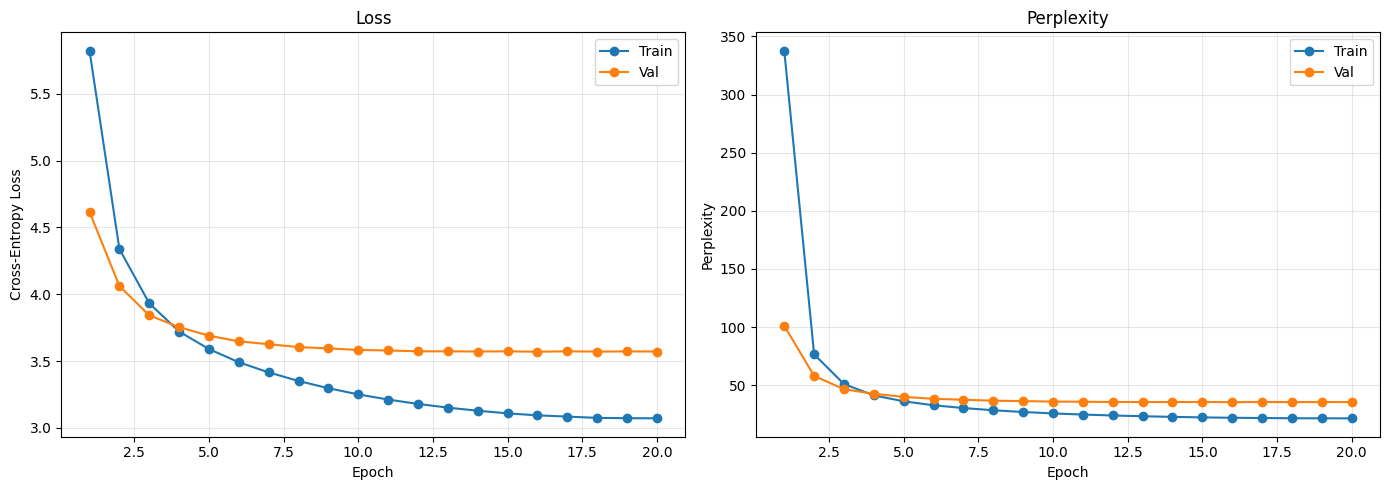

Best val loss: 3.5697  |  Best val PPL: 35.51


In [22]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history['train_ppl'], label='Train', marker='o')
ax2.plot(epochs_ran, history['val_ppl'],   label='Val',   marker='o')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()
print(f"Best val loss: {best_val_loss:.4f}  |  Best val PPL: {math.exp(best_val_loss):.2f}")

## 8. Save Model Artifacts

In [23]:
# ── Save vocabulary ───────────────────────────────────────────────────────────
vocab_data = {
    'word2idx':    word2idx,
    'idx2word':    idx2word,
    'vocab_size':  VOCAB_SIZE,
    'max_seq_len': MAX_SEQ_LEN,
    'special_tokens': {
        'PAD':   word2idx[PAD_TOKEN],
        'START': word2idx[START_TOKEN],
        'END':   word2idx[END_TOKEN],
        'UNK':   word2idx[UNK_TOKEN],
    }
}
with open(SAVE_DIR / 'vocab.json', 'w') as f:
    json.dump(vocab_data, f)
print("Saved vocab.json")

# ── Save model config ─────────────────────────────────────────────────────────
model_config = {
    'vocab_size': VOCAB_SIZE,
    'd_model':    D_MODEL,
    'n_heads':    N_HEADS,
    'n_layers':   N_LAYERS,
    'd_ff':       D_FF,
    'dropout':    DROPOUT,
    'max_len':    MAX_SEQ_LEN + 2,
    'img_size':   IMG_SIZE,
}
with open(SAVE_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f)
print("Saved model_config.json")

# ── Save training history ─────────────────────────────────────────────────────
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)
print("Saved training_history.json")

# ── Final checkpoint (last epoch weights) ─────────────────────────────────────
torch.save({
    'epoch':           epoch,
    'model_state':     model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'best_val_loss':   best_val_loss,
    'history':         history,
}, SAVE_DIR / 'last_checkpoint.pt')
print("Saved last_checkpoint.pt")

print("\nAll artifacts saved to:", SAVE_DIR)
print("  best_model.pt         — best weights (lowest val loss)")
print("  last_checkpoint.pt    — full checkpoint for resuming")
print("  vocab.json            — word↔index mappings")
print("  model_config.json     — hyperparameters for inference.ipynb")
print("  training_history.json — loss/ppl per epoch")
print("  training_curves.png   — loss & perplexity plots")

Saved vocab.json
Saved model_config.json
Saved training_history.json
Saved last_checkpoint.pt

All artifacts saved to: /kaggle/working
  best_model.pt         — best weights (lowest val loss)
  last_checkpoint.pt    — full checkpoint for resuming
  vocab.json            — word↔index mappings
  model_config.json     — hyperparameters for inference.ipynb
  training_history.json — loss/ppl per epoch
  training_curves.png   — loss & perplexity plots
